# Explore Data

In [3]:
import pandas as pd
import os
csv_file="/home/samiksya/ai_job_market/data/raw/ai_jobs.csv"
df = pd.read_csv(csv_file)
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [5]:
df.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


In [6]:
df.isna().sum()

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

# Data Cleaning

## convert date columns

In [8]:
df['posting_date'] = pd.to_datetime(df['posting_date'])
df['application_deadline'] = pd.to_datetime(df['application_deadline'])


In [9]:
df.dtypes

job_id                            object
job_title                         object
salary_usd                         int64
salary_currency                   object
experience_level                  object
employment_type                   object
company_location                  object
company_size                      object
employee_residence                object
remote_ratio                       int64
required_skills                   object
education_required                object
years_experience                   int64
industry                          object
posting_date              datetime64[ns]
application_deadline      datetime64[ns]
job_description_length             int64
benefits_score                   float64
company_name                      object
dtype: object

## Validate date ranges

In [10]:
invalid_dates = df[df['posting_date'] >= df['application_deadline']]
print(f" Invalid date ranges found: {len(invalid_dates)}")

 Invalid date ranges found: 0


## Add new column

In [11]:
df['days_open'] = (df['application_deadline'] - df['posting_date']).dt.days


In [12]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name,days_open
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics,20
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc,52
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech,20
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems,63
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics,69


## Drop some columns
(Useless)

In [13]:
df.drop(columns=['job_id','job_description_length'], inplace=True)

In [14]:
df.head()

,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,benefits_score,company_name,days_open
0,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,5.9,Smart Analytics,20
1,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,5.2,TechCorp Inc,52
2,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,9.4,Autonomous Tech,20
3,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,8.6,Future Systems,63
4,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,6.6,Advanced Robotics,69


## Job Title
(Standarization)

In [15]:
df['job_title'] = df['job_title'].str.lower().str.strip()
df['job_title']

0              ai research scientist
1               ai software engineer
2                      ai specialist
3                       nlp engineer
4                      ai consultant
                    ...             
14995              robotics engineer
14996    machine learning researcher
14997                   nlp engineer
14998                     head of ai
14999       computer vision engineer
Name: job_title, Length: 15000, dtype: object

In [16]:
df['job_title'].unique()

array(['ai research scientist', 'ai software engineer', 'ai specialist',
       'nlp engineer', 'ai consultant', 'ai architect',
       'principal data scientist', 'data analyst',
       'autonomous systems engineer', 'ai product manager',
       'machine learning engineer', 'data engineer', 'research scientist',
       'ml ops engineer', 'robotics engineer', 'head of ai',
       'deep learning engineer', 'data scientist',
       'machine learning researcher', 'computer vision engineer'],
      dtype=object)

## Salary

<Axes: >

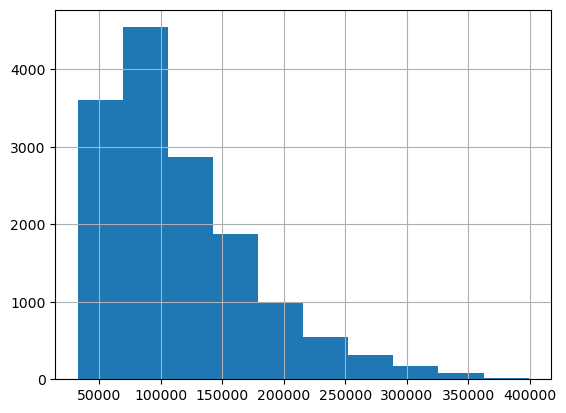

In [17]:
df['salary_usd'].hist()

<Axes: >

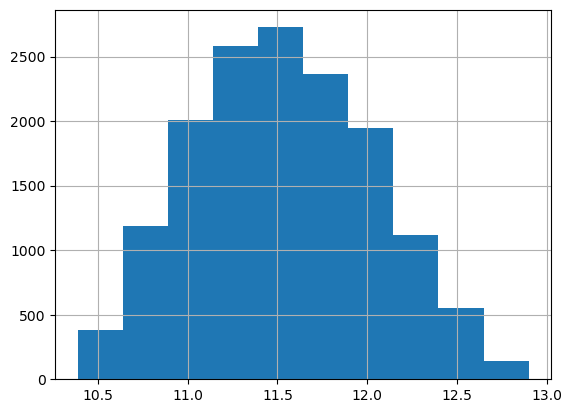

In [18]:
import numpy as np
df['log_salary'] = np.log1p(df['salary_usd'])
df['log_salary'].hist()

In [19]:
# Add new column
df['salary_per_year_exp'] = df['salary_usd'] / (df['years_experience'] + 1)


In [20]:
df.head()

,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,benefits_score,company_name,days_open,log_salary,salary_per_year_exp
0,ai research scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,5.9,Smart Analytics,20,11.411745,9037.600000
1,ai software engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,5.2,TechCorp Inc,52,11.033211,30947.500000
2,ai specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,9.4,Autonomous Tech,20,11.935752,50875.333333
3,nlp engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,8.6,Future Systems,63,11.292478,10026.875000
4,ai consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,6.6,Advanced Robotics,69,10.908247,54624.000000


## cuurency

In [21]:
df['salary_currency'].unique()

array(['USD', 'EUR', 'GBP'], dtype=object)

## Level of Experience & Employment Type

In [22]:
df['experience_level'].unique()

array(['SE', 'EN', 'MI', 'EX'], dtype=object)

In [23]:
exp_map_text = {
    'EN': 'entry_level',
    'MI': 'mid_level',
    'SE': 'senior',
    'EX': 'executive'
}

df['experience_level_text'] = df['experience_level'].map(exp_map_text)


In [24]:
df[['experience_level', 'experience_level_text']].head()

,experience_level,experience_level_text
0,SE,senior
1,EN,entry_level
2,MI,mid_level
3,SE,senior
4,EN,entry_level


In [25]:
exp_map = {
    'entry_level': 0,
    'mid_level': 1,
    'senior': 2,
    'lead': 3,
    'executive': 4
}

df['experience_encoded'] = df['experience_level_text'].map(exp_map)


In [26]:
df[['experience_level', 'experience_level_text','experience_encoded']].head()

,experience_level,experience_level_text,experience_encoded
0,SE,senior,2
1,EN,entry_level,0
2,MI,mid_level,1
3,SE,senior,2
4,EN,entry_level,0


In [27]:
df['employment_type'].unique()

array(['CT', 'FL', 'PT', 'FT'], dtype=object)

In [28]:
emp_map = {
    'FT': 'full_time',
    'PT': 'part_time',
    'CT': 'contract',
    'FL': 'freelance'
}

df['employment_type_text'] = df['employment_type'].map(emp_map)


In [29]:
df[['employment_type','employment_type_text']].head()

,employment_type,employment_type_text
0,CT,contract
1,CT,contract
2,FL,freelance
3,FL,freelance
4,PT,part_time


In [30]:
df = pd.get_dummies(
    df,
    columns=['employment_type_text'],
    prefix='emp',
    drop_first=True
)


## Company Location

In [31]:
df['company_location'].unique()

array(['China', 'Canada', 'Switzerland', 'India', 'France', 'Germany',
       'United Kingdom', 'Singapore', 'Austria', 'Sweden', 'South Korea',
       'Norway', 'Netherlands', 'United States', 'Israel', 'Australia',
       'Ireland', 'Denmark', 'Finland', 'Japan'], dtype=object)

In [32]:
df = df[df['company_location'] != 'Israel']


In [33]:
df['company_location'].value_counts()


company_location
Germany           814
Denmark           778
Canada            769
France            769
Austria           765
Singapore         764
China             763
India             754
Sweden            752
Ireland           750
Switzerland       746
Japan             733
Finland           733
Australia         732
Netherlands       731
United Kingdom    729
United States     724
South Korea       722
Norway            721
Name: count, dtype: int64

In [34]:
df.groupby('company_location')['salary_usd'].mean().sort_values(ascending=False)


company_location
Switzerland       170639.085791
Denmark           165652.249357
Norway            159490.533981
United States     146833.045580
United Kingdom    128720.186557
Singapore         128004.035340
Netherlands       126750.451436
Sweden            123559.753989
Germany           121810.143735
Australia         118238.887978
France            114411.361508
Canada            114253.310793
Finland            88726.242838
Japan              86861.110505
Ireland            86061.044000
South Korea        85842.703601
Austria            85174.530719
China              84899.003932
India              84236.051724
Name: salary_usd, dtype: float64

## Employee Residence & Remote type

In [35]:
df['employee_residence'] = df['employee_residence'].str.strip()


In [36]:
df['same_country'] = (
    df['employee_residence'] == df['company_location']
).astype(int)


In [37]:
df[['company_location','employee_residence','same_country']].head()

,company_location,employee_residence,same_country
0,China,China,1
1,Canada,Ireland,0
2,Switzerland,South Korea,0
3,India,India,1
4,France,Singapore,0


In [38]:
df['remote_ratio'].unique()



array([ 50, 100,   0])

In [39]:
df['remote_type'] = df['remote_ratio'].map({
    0: 'onsite',
    50: 'hybrid',
    100: 'remote'
})


In [40]:
df = pd.get_dummies(
    df,
    columns=['remote_type'],
    prefix='remote',
    drop_first=True
)


## Required Skills

In [41]:
df['required_skills'] = df['required_skills'].str.lower()
df['skills_list'] = df['required_skills'].str.split(', ')


In [42]:
df['num_skills'] = df['skills_list'].apply(len)


In [43]:
df[['required_skills','skills_list','num_skills']].head()

,required_skills,skills_list,num_skills
0,"tableau, pytorch, kubernetes, linux, nlp","[tableau, pytorch, kubernetes, linux, nlp]",5
1,"deep learning, aws, mathematics, python, docker","[deep learning, aws, mathematics, python, docker]",5
2,"kubernetes, deep learning, java, hadoop, nlp","[kubernetes, deep learning, java, hadoop, nlp]",5
3,"scala, sql, linux, python","[scala, sql, linux, python]",4
4,"mlops, java, tableau, python","[mlops, java, tableau, python]",4


In [44]:
print(f"\n Final dataset shape: {df.shape}")


 Final dataset shape: (14249, 30)


# Visualization

In [46]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 10.3 MB/s  0:00:01a 0:00:01 eta 0:00:01

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [47]:
import plotly.io as pio
pio.renderers.default ='notebook_connected'
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

## HeatMap

In [48]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove list columns for correlation
#numerical_cols = [col for col in numerical_cols if col not in ['skills_list']]

correlation_matrix = df[numerical_cols].corr()
fig = go.Figure(data=go.Heatmap(
    z=correlation_matrix.values,
    x=correlation_matrix.columns,
    y=correlation_matrix.columns,
    colorscale='RdBu',
    zmid=0,
    text=correlation_matrix.values,
    texttemplate='%{text:.2f}',
    textfont={"size": 10},
    colorbar=dict(title="Correlation")
))

fig.update_layout(
    title=' Correlation Heatmap - All Numerical Features',
    title_font=dict(size=18, family='Arial Black'),
    width=900,
    height=800,
    xaxis=dict(tickangle=-45, tickfont=dict(size=10)),
    yaxis=dict(tickfont=dict(size=10)),
    template='plotly_white'
)

fig.show(renderer="iframe")


## Salary Vs Log Salary

In [49]:

# IQR Method for ORIGINAL salary_usd
print("\n📊 Outliers in Original Salary (USD):")
Q1_orig = df['salary_usd'].quantile(0.25)
Q3_orig = df['salary_usd'].quantile(0.75)
IQR_orig = Q3_orig - Q1_orig
lower_bound_orig = Q1_orig - 1.5 * IQR_orig
upper_bound_orig = Q3_orig + 1.5 * IQR_orig

outliers_orig = (df['salary_usd'] < lower_bound_orig) | (df['salary_usd'] > upper_bound_orig)
print(f"  → Total outliers: {outliers_orig.sum()} ({outliers_orig.sum()/len(df)*100:.2f}%)")
print(f"  → Lower bound: ${lower_bound_orig:,.0f}")
print(f"  → Upper bound: ${upper_bound_orig:,.0f}")

# IQR Method for LOG salary
print("\n📈 Outliers in Log-Transformed Salary:")
Q1_log = df['log_salary'].quantile(0.25)
Q3_log = df['log_salary'].quantile(0.75)
IQR_log = Q3_log - Q1_log
lower_bound_log = Q1_log - 1.5 * IQR_log
upper_bound_log = Q3_log + 1.5 * IQR_log

outliers_log = (df['log_salary'] < lower_bound_log) | (df['log_salary'] > upper_bound_log)
print(f"  → Total outliers: {outliers_log.sum()} ({outliers_log.sum()/len(df)*100:.2f}%)")
print(f"  → Lower bound: {lower_bound_log:.2f} (${np.expm1(lower_bound_log):,.0f})")
print(f"  → Upper bound: {upper_bound_log:.2f} (${np.expm1(upper_bound_log):,.0f})")

print(f"\n✅ Log transformation reduced outliers by {outliers_orig.sum() - outliers_log.sum()} "
      f"({(outliers_orig.sum() - outliers_log.sum())/outliers_orig.sum()*100:.1f}%)")


📊 Outliers in Original Salary (USD):
  → Total outliers: 454 (3.19%)
  → Lower bound: $-43,964
  → Upper bound: $263,636

📈 Outliers in Log-Transformed Salary:
  → Total outliers: 0 (0.00%)
  → Lower bound: 10.08 ($23,844)
  → Upper bound: 13.00 ($443,944)

✅ Log transformation reduced outliers by 454 (100.0%)


In [50]:
# Interactive visualization with Plotly
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        '📦 Original Salary Box Plot',
        '📊 Original Salary Distribution', 
        '📦 Log Salary Box Plot',
        '📈 Log Salary Distribution'
    ),
    vertical_spacing=0.12,
    horizontal_spacing=0.10
)

# 1. Original salary box plot
fig.add_trace(
    go.Box(y=df['salary_usd'], name='Salary', marker_color='lightblue',
           boxmean='sd'),
    row=1, col=1
)
fig.add_hline(y=upper_bound_orig, line_dash="dash", line_color="red", 
              annotation_text=f"Upper: ${upper_bound_orig:,.0f}", row=1, col=1)
fig.add_hline(y=lower_bound_orig, line_dash="dash", line_color="red",
              annotation_text=f"Lower: ${lower_bound_orig:,.0f}", row=1, col=1)
# 2. Original salary histogram
fig.add_trace(
    go.Histogram(x=df['salary_usd'], nbinsx=50, name='Salary', 
                 marker_color='skyblue', opacity=0.7),
    row=1, col=2
)
fig.add_vline(x=upper_bound_orig, line_dash="dash", line_color="red", row=1, col=2)
fig.add_vline(x=lower_bound_orig, line_dash="dash", line_color="red", row=1, col=2)

# 3. Log salary box plot
fig.add_trace(
    go.Box(y=df['log_salary'], name='Log Salary', marker_color='lightgreen',
           boxmean='sd'),
    row=2, col=1
)
fig.add_hline(y=upper_bound_log, line_dash="dash", line_color="red",
              annotation_text=f"Upper: {upper_bound_log:.2f}", row=2, col=1)
fig.add_hline(y=lower_bound_log, line_dash="dash", line_color="red",
              annotation_text=f"Lower: {lower_bound_log:.2f}", row=2, col=1)
# 4. Log salary histogram
fig.add_trace(
    go.Histogram(x=df['log_salary'], nbinsx=50, name='Log Salary',
                 marker_color='lightgreen', opacity=0.7),
    row=2, col=2
)
fig.add_vline(x=upper_bound_log, line_dash="dash", line_color="red", row=2, col=2)
fig.add_vline(x=lower_bound_log, line_dash="dash", line_color="red", row=2, col=2)

# Update layout
fig.update_xaxes(title_text="Salary (USD)", row=1, col=2)
fig.update_xaxes(title_text="Log(Salary)", row=2, col=2)
fig.update_yaxes(title_text="Salary (USD)", row=1, col=1)
fig.update_yaxes(title_text="Frequency", row=1, col=2)
fig.update_yaxes(title_text="Log(Salary)", row=2, col=1)
fig.update_yaxes(title_text="Frequency", row=2, col=2)

fig.update_layout(
    title_text="🔍 Outlier Analysis: Original vs Log-Transformed Salary",
    title_font=dict(size=18, family='Arial Black'),
    showlegend=False,
    height=800,
    width=1200,
    template='plotly_white'
)

fig.show(renderer="iframe")

## What is the distribution of salaries?

In [51]:
import plotly.express as px
import plotly.graph_objects as go
fig = px.violin(df, y='salary_usd', box=True, points='outliers',
                title='📊 Salary Distribution (USD)',
                labels={'salary_usd':'Salary (USD)'},
                color_discrete_sequence=['#FF6B6B'])
fig.update_layout(template='plotly_white', height=500)
fig.show(renderer="iframe")


##  How does experience level affect salary?

In [52]:


salary_by_exp = df.groupby('experience_level_text')['salary_usd'].agg(['mean', 'median']).reset_index()
fig = go.Figure(data=[
    go.Bar(name='Mean', x=salary_by_exp['experience_level_text'],
           y=salary_by_exp['mean'], marker_color='#4ECDC4'),
    go.Bar(name='Median', x=salary_by_exp['experience_level_text'],
           y=salary_by_exp['median'], marker_color='#95E1D3')
])
fig.update_layout(title='💼 Salary by Experience Level',
                  xaxis_title='Experience Level',
                  yaxis_title='Salary (USD)',
                  barmode='group',
                  template='plotly_white',
                  height=500)
fig.show(renderer="iframe")

## How does employment type impact salary?

In [53]:


df['employment_type_text'] = df['employment_type'].map(emp_map)

emp_summary = df.groupby('employment_type_text')['salary_usd'].agg(['mean','count']).reset_index()
fig = px.sunburst(emp_summary, path=['employment_type_text'], values='count',
                  color='mean', color_continuous_scale='Viridis',
                  title='🏢 Salary by Employment Type',
                  labels={'mean':'Avg Salary', 'count':'Job Count'})
fig.update_layout(height=500)
fig.show(renderer="iframe")

## Which company locations offer the highest salaries?

In [54]:

top_countries = df.groupby('company_location')['salary_usd'].mean().sort_values(ascending=True).tail(10).reset_index()
fig = px.bar(top_countries, y='company_location', x='salary_usd',
             orientation='h',
             title='🌍 Top 10 Countries by Average Salary',
             labels={'company_location':'Country','salary_usd':'Average Salary (USD)'},
             color='salary_usd',
             color_continuous_scale='Blues')
fig.update_layout(template='plotly_white', height=500)
fig.show(renderer="iframe")

##  Does working in the same country as the company affect salary?

In [55]:

same_country_stats = df.groupby('same_country')['salary_usd'].mean().reset_index()
same_country_stats['label'] = same_country_stats['same_country'].map({0:'Different Country', 1:'Same Country'})
fig = px.bar(same_country_stats, x='label', y='salary_usd',
             title='🗺️ Average Salary: Same Country vs Different Country',
             labels={'label':'Location Type','salary_usd':'Average Salary (USD)'},
             color='label',
             color_discrete_sequence=['#FFB6C1', '#FF69B4'],
             text='salary_usd')
fig.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig.update_layout(template='plotly_white', height=500, showlegend=False)
fig.show(renderer="iframe")

## Does the number of skills affect salary?

In [56]:

colors = px.colors.qualitative.Set2
fig = px.scatter(df, x='num_skills', y='salary_usd',
                 color='experience_level_text',
                 size='salary_usd',
                 title='🎯 Number of Skills vs Salary',
                 labels={'num_skills':'Number of Skills','salary_usd':'Salary (USD)',
                         'experience_level_text':'Experience Level'},
                 color_discrete_sequence=colors,
                 opacity=0.6)
fig.update_layout(template='plotly_white', height=500)
fig.show(renderer="iframe")

## Which industries offer the highest salaries?

In [57]:
top_industries = df.groupby('industry')['salary_usd'].mean().sort_values(ascending=False).head(10).reset_index()
fig = px.bar_polar(top_industries, r='salary_usd', theta='industry',
                   title='🏭 Top 10 Industries by Average Salary',
                   color='salary_usd',
                   color_continuous_scale='Rainbow')
fig.update_layout(height=600)
fig.show(renderer="iframe")

## What are the most common job titles?

In [58]:
job_counts = df['job_title'].value_counts().head(10).reset_index()
job_counts.columns = ['job_title', 'count']
fig = px.bar(job_counts, x='count', y='job_title',
             orientation='h',
             title='📋 Top 10 Most Common Job Titles',
             labels={'job_title':'Job Title','count':'Number of Postings'},
             color='count',
             color_continuous_scale='Purples')
fig.update_layout(template='plotly_white', height=500, yaxis={'categoryorder':'total ascending'})
fig.show(renderer="iframe")

## Which job titles offer the highest salaries?

In [59]:
top_jobs = df.groupby('job_title')['salary_usd'].mean().sort_values(ascending=False).head(10).reset_index()
fig = px.bar(top_jobs, x='salary_usd', y='job_title',
             orientation='h',
             title='💼 Top 10 Job Titles by Average Salary',
             labels={'job_title':'Job Title','salary_usd':'Average Salary (USD)'},
             color='salary_usd',
             color_continuous_scale='Teal')
fig.update_layout(template='plotly_white', height=600, yaxis={'categoryorder':'total ascending'})
fig.show(renderer="iframe")